In [ ]:
#
#Entering Kaggle data Analysis 
#Luis G
#

import pandas as pd # type: ignore
import scipy.stats as stats # type: ignore
import statsmodels.stats.power as smp  # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns  # type: ignore

print("All Libraries loaded Successfully!")


All Libraries loaded Successfully!


In [ ]:
# Random converstion
import numpy as np

# Setting a seed 
np.random.seed(42)

#A/B Simulate Test data
n = 5000 #Users per Group

control = pd.DataFrame({
        
    'group': 'control',
    'converted': np.random.binomial(1, 0.10, n) # 10% based converstion rate 
})

treatment = pd.DataFrame ({
    'group': 'treatment',
    'converted': np.random.binomial(1, 0.12, n) # 12% with new Future
})

df = pd.concat([control, treatment],ignore_index=True)
print(df.groupby('group')['converted'].agg(['sum','mean', 'count']))

           sum    mean  count
group                        
control    479  0.0958   5000
treatment  567  0.1134   5000


In [ ]:
# run chi-square to check for statististcal significance 

control_converter = df[df['group'] == 'control']['converted'].sum()
treatment_converter = df[df['group'] == 'treatment']['converted'].sum()

control_total = len(df[df['group'] == 'control'])
treatment_total = len(df[df['group'] == 'treatment'])

contingency_table = [[control_converter, control_total - control_converter],
                     [treatment_converter, treatment_total - treatment_converter]]
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("\n Good Result is statistically significant - new Future Works!")
else:
    print("\n No Good Results are NOT significant - could be a random chance" )





Chi-square statistic: 8.0815
P-value: 0.0045
Degrees of freedom: 1

 Good Result is statistically significant - new Future Works!


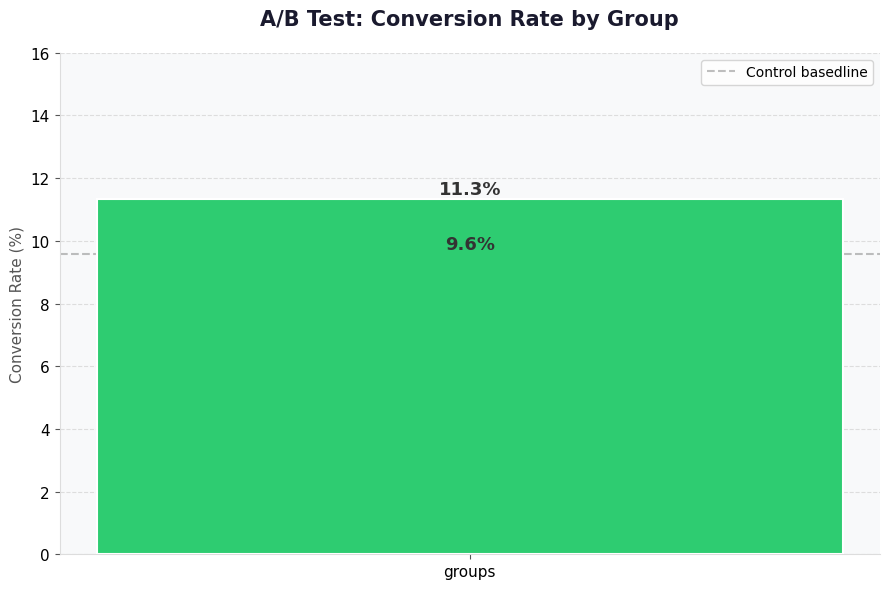

Chart Saved


In [ ]:
# Visual Results chart

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#FFFFFF')

groups = ['Control', 'Treatment']
rates = [
    df[df['group']== 'control']['converted'].mean()*100,
    df[df['group']== 'treatment']['converted'].mean()*100
]

colors = ['#5B7FA6', '#2ECC71']
bars = ax.bar('groups', rates, color=colors, width=0.35,
              edgecolor='white', linewidth =1.5, zorder=3)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.15,
            f'{rate:.1f}%',
            ha='center', fontsize=13, fontweight='bold',color='#333333')
    
ax.set_title('A/B Test: Conversion Rate by Group', fontsize=15, fontweight='bold', pad=20, color='#1A1A2E')
ax.set_ylabel('Conversion Rate (%)',fontsize=11, color='#555555')
ax.set_ylim(0, 16)
ax.yaxis.grid(True, color='#DDDDDD', linestyle='--', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.tick_params(color='#555555', labelsize=11)
ax.axhline(y=rates[0], color='gray', linestyle='--', alpha=0.5, label='Control basedline')
ax.legend()

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150)
plt.show()
print("Chart Saved")

    






In [ ]:
# Summary 

lift = (rates[1] - rates[0]) /rates[0] * 100

print("=" * 50)
print( "     A / B  TEST SUMMARY")
print("=" * 50)
print(f"""
      BUSINESS QUESTION:
      Does the new future improves user conversion?
      
      TESTING DESIGN:
      - Control Group: {control_total:,} users (existing  experience)
      - Treatment Group: {treatment_total:,} users (new feature)
      
      RESULTS:
      - Control Conversion Rate: {rates[0]:.1f}%
      - Treatment Conversion Rates: {rates[1]:.1f}%
      - Relative lift: +{lift:.1}%

      STATISTCAL VALIDITY:
      - P-value: {p_value:.4f} (threshold: 0.05)
      - Result: Statistically significant GOOD

      RECOMMENDATION:
      Ship to new feature. At current traffict levels, a {lift:.0f} lift in conversion represents meaningful business impact.
      Recommend monitoring for 2 weeks post launch to confirm results hold at scale.
    
""")

print("=" * 50) 

     A / B  TEST SUMMARY

      BUSINESS QUESTION:
      Does the new future improves user conversion?

      TESTING DESIGN:
      - Control Group: 5,000 users (existing  experience)
      - Treatment Group: 5,000 users (new feature)

      RESULTS:
      - Control Conversion Rate: 9.6%
      - Treatment Conversion Rates: 11.3%
      - Relative lift: +2e+01%

      STATISTCAL VALIDITY:
      - P-value: 0.0045 (threshold: 0.05)
      - Result: Statistically significant GOOD

      RECOMMENDATION:
      Ship to new feature. At current traffict levels, a 18 lift in conversion represents meaningful business impact.
      Recommend monitoring for 2 weeks post launch to confirm results hold at scale.


